In [121]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [ ]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

# 真实权重和偏差
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [123]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-0.8152,  0.6936]) 
label: tensor([0.2105])


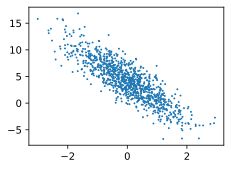

In [124]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [125]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [126]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 1.1888, -0.9872],
        [-1.3929, -0.7324],
        [ 1.1312, -0.9337],
        [-1.0655, -0.5058],
        [ 0.2437,  0.5948],
        [ 1.6065, -1.1668],
        [ 0.5963,  0.8292],
        [ 0.4412,  0.6061],
        [-0.0797,  2.4226],
        [-0.6865,  1.1244]]) 
 tensor([[ 9.9402],
        [ 3.8928],
        [ 9.6415],
        [ 3.8137],
        [ 2.6706],
        [11.3771],
        [ 2.5729],
        [ 3.0175],
        [-4.1875],
        [-0.9864]])


In [127]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
print(w)
print(b)


tensor([[ 0.0261],
        [-0.0113]], requires_grad=True)
tensor([0.], requires_grad=True)


In [128]:
def linreg(X, w, b):  #@save
    """线性回归模型"""
    # print(X),
    # print(w),
    # print(b),
    return torch.matmul(X, w) + b

In [129]:
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [130]:
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            # print(param.grad)
            param -= lr * param.grad / batch_size
            param.grad.zero_()
            
            

In [135]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
idx = 0

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        # print("y=", y)
        A = net(X, w, b)
        # print("A=", A)
        l = loss(A, y)  # X和y的小批量损失
        # print("l=", l)
        
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
        idx += 1
        # if idx % 10 == 0:
            # print(f'epoch {epoch + 1}, batch {idx}, loss {float(l.mean()):f}')
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.000050
epoch 2, loss 0.000050
epoch 3, loss 0.000050


In [132]:
for i in range(0, 50, 30):
    print(i)

0
30


In [140]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 0.0003, -0.0001], grad_fn=<SubBackward0>)
b的估计误差: tensor([-0.0002], grad_fn=<RsubBackward1>)
